# **DATASET INFORMATION**

This dataset provides an in-depth look at transaction behavior and financial activity patterns, making it ideal for **fraud detection** and **anomaly identification**. The dataset includes 2,512 transaction data samples, covering a wide range of transaction attributes, customer demographics, and usage patterns.

Each entry provides comprehensive insights into transaction behavior, enabling analysis for financial security and predictive model development.

## Fitur Utama

- **`TransactionID`**: A unique identifier for each transaction.  
- **`AccountID`**: The ID for each account, containing transactions and everything else necessary for the account.
- **`TransactionAmount`**: Transaction value in currency  
- **`TransactionDate`**: Time and date of when the transaction happened.  
- **`TransactionType`**: Types of transaction, 'Credit' or 'Debit'.  
- **`Location`**: Transaction location (a city name in USA).  
- **`DeviceID`**: ID of the device used for transaction.  
- **`IP Address`**: IPv4 address that was used during the transaction, may change for different accounts.  
- **`MerchantID`**:  Unique ID for a merchant.
- **`AccountBalance`**: Balance after the transaction.  
- **`PreviousTransactionDate`**: Date of the last transaction made on the account, useful for calculating the frequency of transactions  
- **`Channel`**: Transaction channel like `Online`, `ATM`, or `Branch`.  
- **`CustomerAge`**: Age of the account owner.
- **`CustomerOccupation`**: Owner profession like `Dokter`, `Insinyur`, `Mahasiswa`, or `Pensiunan`.  
- **`TransactionDuration`**: Time it took for the transaction(in seconds).   
- **`LoginAttempts`**: The amount of login attempts before transaction, a high number of attempts may indicate an anomaly.


# **1. Import Library**

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from yellowbrick.cluster import KElbowVisualizer

# **2. Load Datasets**

In [ ]:
url='https://docs.google.com/spreadsheets/d/e/2PACX-1vTbg5WVW6W3c8SPNUGc3A3AL-AG32TPEQGpdzARfNICMsLFI0LQj0jporhsLCeVhkN5AoRsTkn08AYl/pub?output=csv'
df_raw = pd.read_csv(url)

df_cleaned = df_raw.copy()

# **3. Data Cleaning**

In [ ]:
# Drop rows with any null values
df_cleaned.dropna(inplace=True)

# Drop duplicate rows
df_cleaned.drop_duplicates(inplace=True)

print("Null values after cleaning:")
print(df_cleaned.isnull().sum())
print("\nDuplicate rows after cleaning:")
print(df_cleaned.duplicated().sum())

Null values after cleaning:
TransactionID              0
AccountID                  0
TransactionAmount          0
PreviousTransactionDate    0
TransactionType            0
Location                   0
DeviceID                   0
IP Address                 0
MerchantID                 0
Channel                    0
CustomerAge                0
CustomerOccupation         0
TransactionDuration        0
LoginAttempts              0
AccountBalance             0
TransactionDate            0
dtype: int64

Duplicate rows after cleaning:
0


In [ ]:
features_for_clustering = [
    'TransactionAmount',
    'TransactionDuration',
    'LoginAttempts',
    'AccountBalance'
]

df_features = df_cleaned[features_for_clustering].copy()

# Initialize the StandardScaler
scaler = StandardScaler()

df_scaled_features = pd.DataFrame(scaler.fit_transform(df_features),
                                     columns=features_for_clustering,
                                     index=df_features.index)

# **4. Clustering**

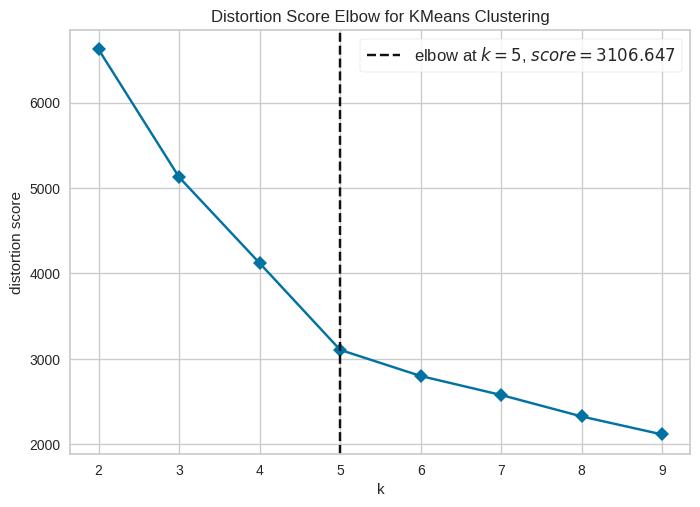

In [ ]:
# Create clustering model
model = KMeans(random_state=42)
visualizer = KElbowVisualizer(model,
                       k=(2,10),
                       timings=False)

visualizer.fit(df_scaled_features)

visualizer.show()

kmeans = KMeans(n_clusters=5, random_state=42)
kmeans.fit(df_scaled_features)

# Add the cluster labels to the scaled features DataFrame
df_scaled_features['Target'] = kmeans.labels_

calculate the anomaly score for each data point by computing its Euclidean distance to the centroid of its assigned cluster.



In [ ]:
centroids = kmeans.cluster_centers_

anomaly_scores = []

feature_cols = df_scaled_features.drop(columns=['Target']).columns

for index, row in df_scaled_features.iterrows():
    features = row[feature_cols].values

    cluster_label = int(row['Target'])

    cluster_centroid = centroids[cluster_label]

    distance = np.linalg.norm(features - cluster_centroid)
    anomaly_scores.append(distance)

df_scaled_features['Anomaly_Score'] = anomaly_scores

Calculate the threshold as the 99th percentile of anomaly scores

In [ ]:
# Calculate the threshold as the 99th percentile of anomaly scores
threshold = df_scaled_features['Anomaly_Score'].quantile(0.99)

df_scaled_features['Is_Anomaly'] = (df_scaled_features['Anomaly_Score'] > threshold).astype(int)

print(f"Anomaly Threshold (99th Percentile): {threshold:.2f}")
print(f"Number of Anomalies Detected: {df_scaled_features['Is_Anomaly'].sum()}")

Anomaly Threshold (99th Percentile): 2.81
Number of Anomalies Detected: 22


In [ ]:
df_cleaned_with_anomalies = df_cleaned.merge(df_scaled_features[['Anomaly_Score', 'Is_Anomaly']], left_index=True, right_index=True, how='left')

anomalies_df_original = df_cleaned_with_anomalies[df_cleaned_with_anomalies['Is_Anomaly'] == 1]

display(anomalies_df_original)

,TransactionID,AccountID,TransactionAmount,PreviousTransactionDate,TransactionType,Location,DeviceID,IP Address,MerchantID,Channel,CustomerAge,CustomerOccupation,TransactionDuration,LoginAttempts,AccountBalance,TransactionDate,Anomaly_Score,Is_Anomaly
231,TX000232,AC00430,705.60,2023-02-20 18:41:43,Debit,Phoenix,D000103,205.45.234.42,M071,Branch,40.0,Doctor,124.0,3.0,14804.70,2024-11-04 8:09:04,3.248491,1
274,TX000275,AC00454,1176.28,2023-12-20 16:08:02,Credit,Kansas City,D000476,50.202.8.53,M074,ATM,54.0,Engineer,174.0,5.0,323.69,2024-11-04 8:11:44,3.852357,1
340,TX000341,AC00107,1830.00,2023-03-01 16:31:58,Debit,San Antonio,D000436,62.27.235.199,M082,Online,55.0,Engineer,238.0,1.0,2235.70,2024-11-04 8:11:59,3.730604,1
375,TX000376,AC00316,1392.54,2023-11-20 16:51:14,Debit,El Paso,D000113,63.67.150.226,M013,Branch,41.0,Doctor,297.0,1.0,13347.69,2024-11-04 8:09:15,3.887326,1
394,TX000395,AC00326,6.30,2023-12-14 18:52:54,Debit,Columbus,D000539,210.160.90.52,M017,Branch,80.0,Retired,283.0,5.0,7697.68,2024-11-04 8:12:13,2.986928,1
466,TX000467,AC00063,445.41,2023-11-20 16:27:31,Debit,Fresno,D000039,185.23.87.107,M015,ATM,35.0,Doctor,235.0,3.0,12154.66,2024-11-04 8:08:08,2.820810,1
593,TX000594,AC00039,139.57,2023-11-17 17:59:11,Debit,Fort Worth,D000222,13.30.106.126,M030,ATM,19.0,Student,263.0,3.0,271.78,2024-11-04 8:07:23,2.822026,1
772,TX000773,AC00093,827.14,2023-01-17 17:25:13,Debit,El Paso,D000645,215.97.143.157,M018,Branch,36.0,Engineer,265.0,4.0,9800.21,2024-11-04 8:08:14,2.860473,1
898,TX000899,AC00083,1531.31,2023-10-23 18:00:29,Debit,San Diego,D000319,91.204.200.167,M078,Online,18.0,Student,62.0,4.0,859.86,2024-11-04 8:06:40,4.576485,1
1314,TX001315,AC00452,30.87,2023-07-12 16:50:42,Debit,Fresno,D000015,34.92.221.183,M025,ATM,33.0,Doctor,295.0,1.0,14348.65,2024-11-04 8:10:43,2.934672,1


calculate descriptive statistics for the `anomalies_df_original` DataFrame. This will allow me to identify the key features that distinguish these anomalous data points from the rest of the dataset and provide a comprehensive summary as requested by the subtask.



In [ ]:
display(anomalies_df_original.describe())

,TransactionAmount,CustomerAge,TransactionDuration,LoginAttempts,AccountBalance,Anomaly_Score,Is_Anomaly
count,22.000000,22.000000,22.000000,22.000000,22.000000,22.000000,22.0
mean,926.419091,42.454545,200.000000,2.454545,8999.673182,3.206268,1.0
std,634.775816,18.123196,90.194499,1.595448,5230.565449,0.472721,0.0
min,6.300000,18.000000,50.000000,1.000000,271.780000,2.820810,1.0
25%,412.572500,30.750000,111.250000,1.000000,3601.195000,2.872568,1.0
50%,981.470000,38.500000,244.000000,2.000000,11005.765000,3.003229,1.0
75%,1482.877500,57.250000,277.750000,3.750000,13221.020000,3.271529,1.0
max,1831.020000,80.000000,297.000000,5.000000,14804.700000,4.576485,1.0


In [ ]:
no_anomalies_df_original = df_cleaned_with_anomalies[df_cleaned_with_anomalies['Is_Anomaly'] == 0]

display(no_anomalies_df_original.describe())

,TransactionAmount,CustomerAge,TransactionDuration,LoginAttempts,AccountBalance,Anomaly_Score,Is_Anomaly
count,2113.000000,2113.000000,2113.000000,2113.000000,2113.000000,2113.000000,2113.0
mean,291.554245,44.645528,119.321344,1.103644,5052.914614,1.080258,0.0
std,278.171438,17.835150,70.184581,0.541944,3884.755009,0.440642,0.0
min,0.260000,18.000000,10.000000,1.000000,102.200000,0.045994,0.0
25%,82.170000,27.000000,63.000000,1.000000,1479.670000,0.793078,0.0
50%,211.690000,45.000000,112.000000,1.000000,4586.110000,1.029658,0.0
75%,406.810000,59.000000,161.000000,1.000000,7620.600000,1.263053,0.0
max,1612.370000,80.000000,300.000000,5.000000,14977.990000,2.801235,0.0


In [ ]:
categorical_cols_all = df_cleaned.select_dtypes(include=['object']).columns.tolist()

categorical_cols = ['TransactionType', 'Location', 'Channel', 'CustomerOccupation']

print("Mode of Categorical Features for Anomalous Data:")
for col in categorical_cols:
    if col in anomalies_df_original.columns:
        mode_value = anomalies_df_original[col].mode().iloc[0]
        print(f"  {col}: {mode_value}")

print("\nMode of Categorical Features for Non-Anomalous Data:")
for col in categorical_cols:
    if col in no_anomalies_df_original.columns:
        mode_value = no_anomalies_df_original[col].mode().iloc[0]
        print(f"  {col}: {mode_value}")

Mode of Categorical Features for Anomalous Data:
  TransactionType: Debit
  Location: Columbus
  Channel: ATM
  CustomerOccupation: Doctor

Mode of Categorical Features for Non-Anomalous Data:
  TransactionType: Debit
  Location: Fort Worth
  Channel: Branch
  CustomerOccupation: Student


## Summary

1.  Anomaly detection was performed by first applying K-Means clustering to a scaled feature set (`TransactionAmount`, `TransactionDuration`, `LoginAttempts`, `AccountBalance`). Then, for each data point, its Euclidean distance to the centroid of its assigned cluster was calculated, serving as an "anomaly score." Finally, a statistical threshold, defined as the 99th percentile, was used to identify data points with scores exceeding this threshold as anomalies.
2.  Based on the defined statistical threshold, **22 anomalies** were detected out of 2135 total transactions.
3.  Comparing the descriptive statistics of the anomalous transactions to the no anomalous data reveals:
    *   **TransactionAmount**: Anomalies tend to have significantly *higher* transaction amounts (mean 926.41) compared to the non (mean 291.55).
    *   **TransactionDuration**: Anomalous transactions generally have *longer* durations (mean 200 seconds) than the non (mean 119.32 seconds).
    *   **LoginAttempts**: Anomalies show a *higher* average number of login attempts (mean 2.45) than the non (mean 1.10), with a wider range, suggesting some anomalies are associated with multiple login attempts.

# **5. Visualization**

Generate a 2D PCA plot of the clustered data, highlighting the detected anomalies and cluster centroids for visual interpretation.

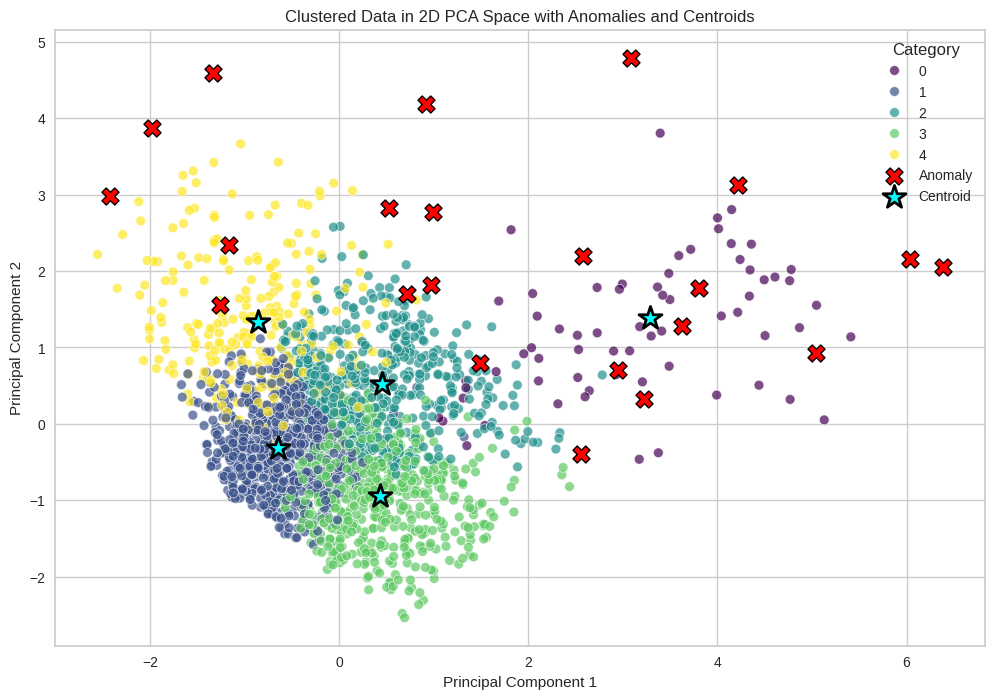

In [ ]:
feature_cols_for_pca = [
    'TransactionAmount',
    'TransactionDuration',
    'LoginAttempts',
    'AccountBalance'
]
X_for_pca = df_scaled_features[feature_cols_for_pca].values

pca = PCA(n_components=2, random_state=42)
pca.fit(X_for_pca)

X_pca_transformed = pca.transform(X_for_pca)

df_pca_results = pd.DataFrame(data=X_pca_transformed, columns=['Principal Component 1', 'Principal Component 2'], index=df_scaled_features.index)
df_pca_results['Target'] = df_scaled_features['Target']
df_pca_results['Is_Anomaly'] = df_scaled_features['Is_Anomaly']

centroids_pca_transformed = pca.transform(kmeans.cluster_centers_)

# Create a scatter plot
plt.figure(figsize=(12, 8))

sns.scatterplot(
    x='Principal Component 1',
    y='Principal Component 2',
    hue='Target',
    data=df_pca_results,
    palette='viridis', # Choose a color palette
    s=50, # Marker size
    alpha=0.7, # Transparency
    legend='full'
)

# Overlay anomalies
anomalies_pca_results = df_pca_results[df_pca_results['Is_Anomaly'] == 1]
plt.scatter(
    anomalies_pca_results['Principal Component 1'],
    anomalies_pca_results['Principal Component 2'],
    marker='X',
    s=150,
    color='red',
    edgecolors='black',
    linewidth=1,
    label='Anomaly'
)

# Overlay PCA-transformed cluster centroids
plt.scatter(
    centroids_pca_transformed[:, 0],
    centroids_pca_transformed[:, 1],
    marker='*',
    s=300,
    color='cyan',
    edgecolors='black',
    linewidth=2,
    label='Centroid'
)

plt.title('Clustered Data in 2D PCA Space with Anomalies and Centroids')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')

plt.legend(title='Category')
plt.grid(True)
plt.show()

## Analyze Numerical Features per Cluster



In [ ]:
# Inverse transform the scaled features
df_original_features = pd.DataFrame(scaler.inverse_transform(df_scaled_features[features_for_clustering]),
                                      columns=features_for_clustering,
                                      index=df_scaled_features.index)

df_original_features['Target'] = df_scaled_features['Target']

cluster_descriptive_stats_original = df_original_features.groupby('Target').describe()
display(cluster_descriptive_stats_original.T)

Target                                0            1             2  \
TransactionAmount   count     77.000000   734.000000    492.000000   
                    mean     279.489091   196.411444    208.403069   
                    std      275.165261   149.494172    156.915173   
                    min        1.930000     0.840000      0.260000   
                    25%       95.230000    67.702500     74.842500   
                    50%      192.230000   164.500000    185.020000   
                    75%      403.010000   304.007500    316.095000   
                    max     1531.310000   605.420000    734.860000   
TransactionDuration count     77.000000   734.000000    492.000000   
                    mean     134.389610    76.269755    208.839431   
                    std       74.582550    38.925938     48.177758   
                    min       11.000000    10.000000    135.000000   
                    25%       85.000000    44.000000    167.000000   
                    50%      129.000000    72.500000    198.500000   
                    75%      174.000000   108.000000    251.000000   
                    max      291.000000   152.000000    300.000000   
LoginAttempts       count     77.000000   734.000000    492.000000   
                    mean       3.948052     1.010899      1.012195   
                    std        0.809420     0.103899      0.109868   
                    min        3.000000     1.000000      1.000000   
                    25%        3.000000     1.000000      1.000000   
                    50%        4.000000     1.000000      1.000000   
                    75%        5.000000     1.000000      1.000000   
                    max        5.000000     2.000000      2.000000   
AccountBalance      count     77.000000   734.000000    492.000000   
                    mean    5452.108701  2565.070313   4180.331341   
                    std     4214.466839  1918.815329   3111.360836   
                    min      271.780000   105.010000    112.760000   
                    25%     1544.880000   976.952500   1431.405000   
                    50%     4976.180000  1837.465000   3762.755000   
                    75%     7910.300000  4157.155000   6385.220000   
                    max    14851.280000  6852.160000  14348.650000   

Target                                3             4  
TransactionAmount   count    548.000000    284.000000  
                    mean     220.936277    870.215810  
                    std      180.647293    271.046472  
                    min        0.320000    508.160000  
                    25%       72.802500    659.890000  
                    50%      173.850000    795.635000  
                    75%      332.022500   1023.677500  
                    max      813.780000   1831.020000  
TransactionDuration count    548.000000    284.000000  
                    mean      97.768248    119.260563  
                    std       49.423691     63.277412  
                    min       10.000000     10.000000  
                    25%       55.750000     68.750000  
                    50%       99.000000    118.000000  
                    75%      137.500000    157.250000  
                    max      269.000000    300.000000  
LoginAttempts       count    548.000000    284.000000  
                    mean       1.010949      1.014085  
                    std        0.104158      0.118047  
                    min        1.000000      1.000000  
                    25%        1.000000      1.000000  
                    50%        1.000000      1.000000  
                    75%        1.000000      1.000000  
                    max        2.000000      2.000000  
AccountBalance      count    548.000000    284.000000  
                    mean    9774.946259   4080.400845  
                    std     2518.148197   3310.829428  
                    min     5958.340000    102.200000  
                    25%     7600.622500   1184.767500  
         

1. **Cluster 0**: The Potential Risk Users
Population: 77 transactions (Smallest group)
*   Defining Characteristic: Multiple Login Attempts

    Login Attempts: Mean of 3.95 (Min: 3, Max: 5). Every other cluster averages ~1 attempt.

Transaction Amount: Moderate (~$279).

Duration: Moderate (~134s).

Analysis: This is a distinct group of users who struggled to log in, requiring 3 to 5 attempts. While their transaction amounts are not the highest, the friction at login suggests either forgotten passwords or potential brute-force attempts. This cluster represents the highest security risk among the groups.

2. **Cluster 1**: The "Quick & Thrifty" Users
Population: 734 transactions (Largest group)
*   Defining Characteristic: Speed and Low Value

    Duration: 76 seconds (Fastest average).
Transaction Amount: $196 (Lowest average).

Account Balance: $2,565 (Lowest average).

Analysis: These are highly efficient users making small, routine purchases. They likely use autofill or saved payments (short duration) and do not hold large balances. This represents the "standard" low-risk traffic.

3. **Cluster 2**: The "Slow Browsers"
Population: 492 transactions
*   Defining Characteristic: Long Transaction

    Duration: 209 seconds (Highest average).

Transaction Amount: Low (~$208).

Analysis: Despite spending small amounts similar to Cluster 1, these users take nearly 3x longer to complete the process. This behavior is typical of less tech-savvy users, manual data entry (typing card numbers instead of autofill), or distracted browsing.

4. **Cluster 3**: The "High Net-Worth Savers"
Population: 548 transactions
*   Defining Characteristic: Massive Account Balance

    Account Balance: $9,775 (Highest average).

Transaction Amount: Low (~$221).

Analysis: These customers hold significant funds (nearly 2.5x the average of other clusters) but are currently making small transactions. They are valuable "VIP" customers in terms of holdings but are conservative in this specific transaction instance.

5. **Cluster 4**: The "Big Spenders"
Population: 284 transactions
*   Defining Characteristic: High Transaction Value

    Transaction Amount: $870 (Highest average).

Comparison: This is ~4x higher than the average spend of Clusters 1, 2, and 3.

Analysis: This group represents high-value transfers or purchases. While the amount is high, the duration (119s) and login attempts (1.0) are normal, suggesting these are likely legitimate large purchases rather than fraud (unless combined with other risk signals).